# Notebook 05 - LoRA Fine-Tuning

## Objective

This notebook fine-tunes Mistral 7B Instruct on the task of generating product
descriptions from structured metadata, using the original Amazon descriptions
as training targets.

**Why fine-tuning?**
In Notebooks 02 and 04, Mistral 7B generates descriptions via prompt engineering
and RAG — relying on in-context examples at inference time. Fine-tuning bakes the
generation style directly into the model weights:
- No retrieval step needed at inference
- Lower latency
- Better generalization on unseen products
- Direct comparison baseline vs fine-tuned on identical metrics

**Method: QLoRA (Quantized Low-Rank Adaptation)**
Instead of updating all 7B parameters (requires ~ 80GB VRAM), we freeze the base
model and train small low-rank adapter matrices injected into the attention layers.
With 4-bit quantization, the full pipeline runs on a free-tier Colab GPU (~ 10GB VRAM).

### Pipeline
1. Prepare instruction → output dataset from filtered Amazon descriptions
2. Format data into Mistral chat template
3. Fine-tune with QLoRA (PEFT + TRL SFTTrainer)
4. Generate descriptions with the fine-tuned model
5. Compare scores vs Notebook 03 baseline (BLEU, ROUGE-L, cosine)

In [1]:
!pip install transformers accelerate peft trl bitsandbytes datasets rouge-score sentence-transformers -q

import pandas as pd
import numpy as np
import json
import torch

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from trl import SFTTrainer, SFTConfig
from datasets import Dataset

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import os

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from google.colab import drive
drive.mount('/content/drive')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.8 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Mounted at /content/drive


## 1 - Load & Prepare Data

In [2]:
# Load generated dataset (Notebook 02)
df = pd.read_json("/content/drive/MyDrive/dataset.jsonl", lines=True)
df = df.drop_duplicates(subset="title", keep="first").reset_index(drop=True)

# Load original dataset with Amazon reference descriptions
df_original = pd.read_csv("clean_products_800.csv")[["title", "description"]]

# Merge
df = df.merge(df_original, on="title", how="left")

print(f"Dataset shape : {df.shape}")
print(f"Missing refs  : {df['description'].isna().sum()}")

Dataset shape : (800, 8)
Missing refs  : 0


### 1.1 - Filter training data

We reuse the same quality filter applied in Notebook 04 to remove
low-quality Amazon descriptions from the training set.

Training on logistic text or generic boilerplate would teach the model
the wrong output format — we only keep genuine product descriptions.

In [3]:
df_corpus = df[
    df["description"].notna() &
    (df["description"].str.len() > 80) &
    (~df["description"].str.contains("shipping|delivery|days", case=False)) &
    (~df["description"].str.contains("Factory Direct|actual manufacturer", case=False))
].reset_index(drop=True)

print(f"Training corpus : {len(df_corpus)} / {len(df)} products after filtering")

Training corpus : 680 / 800 products after filtering


### 1.2 - Format as instruction dataset

Each training example is formatted as a Mistral chat template:
- **Input (user)**: structured metadata prompt
- **Output (assistant)**: original Amazon description

This is the standard instruction-tuning format — the model learns to map
metadata → description directly, without needing few-shot examples at inference.

In [4]:
tokenizer_format = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.3")

def format_example(row):
    """
    Format a single product as a Mistral instruction-tuning example.
    Returns the full conversation formatted with the chat template.
    """

    user_message = f"""Write a clear technical product description using ONLY the information below.
Do not invent specifications, materials, or features.
Do not make verifiable claims that are not supported by the data.
Do not mention missing data or absent specifications.
For example, never write "steel construction", "integrated microphone", "embroidered logos" unless stated in the data.

Title: {row["title"]}
Brand: {row["brand"]}
Category: {row["category"]}
Price: {row["price"]}

Write 3–4 technical sentences. No bullet points. No emojis."""

    messages = [
        {"role": "user",      "content": user_message},
        {"role": "assistant", "content": row["description"]}
    ]

    return tokenizer_format.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )

# Apply formatting
df_corpus["text"] = df_corpus.apply(format_example, axis=1)

# Verify
print(f"Training examples : {len(df_corpus)}")
print("\nExample formatted input:\n")
print(df_corpus["text"].iloc[0][:500] + "...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Training examples : 680

Example formatted input:

<s>[INST] Write a clear technical product description using ONLY the information below.
Do not invent specifications, materials, or features.
Do not make verifiable claims that are not supported by the data.
Do not mention missing data or absent specifications.
For example, never write "steel construction", "integrated microphone", "embroidered logos" unless stated in the data.

Title: Nikon DSLR Bag with Online Class Camera Case, Black (9793)
Brand: Nikon
Category: Camera Cases
Price: $44.95

W...


In [5]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df_corpus,
    test_size=0.15,
    random_state=42
)

print(f"Train : {len(df_train)} examples")
print(f"Test  : {len(df_test)} examples")

# Convert to HuggingFace Dataset
train_dataset = Dataset.from_pandas(df_train[["text"]].reset_index(drop=True))
test_dataset  = Dataset.from_pandas(df_test[["text"]].reset_index(drop=True))

Train : 578 examples
Test  : 102 examples


## 2 - Model Setup

### QLoRA configuration

We use QLoRA (Dettmers et al., 2023): the base model is loaded in 4-bit
and frozen, while small low-rank adapter matrices (rank=16) are trained
on top of the attention layers.

**LoRA hyperparameters: (Run 1)**
- `r=16` : rank of the adapter matrices — controls capacity vs parameter count
- `lora_alpha=32` : scaling factor, typically set to 2×r
- `lora_dropout=0.05` : light regularization
- `target_modules` : we target all attention projection layers for maximum coverage

**LoRA hyperparameters: (Run 2)**
- `r=8`
- `lora_alpha=16`

In [8]:
model_name = "mistralai/Mistral-7B-Instruct-v0.3"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
)

model.config.use_cache = False
model.config.pretraining_tp = 1

print("Base model loaded.")

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Base model loaded.


In [11]:
lora_config = LoraConfig(
    r=8,           #16, # matrix rank
    lora_alpha=16, #32, # scale factor, 2*r usually
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj", # attention layer
        "gate_proj", "up_proj", "down_proj" # feed-forward layer
    ]
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


trainable params: 20,971,520 || all params: 7,268,995,072 || trainable%: 0.2885


## 3 - Fine-Tuning

### Training configuration - Run 1

- `num_train_epochs=3` : 3 full passes over the training data
- `per_device_train_batch_size=2` : small batch to fit Colab VRAM
- `gradient_accumulation_steps=4` : effective batch size = 2×4 = 8
- `save_strategy="steps"` / `save_steps=50` : checkpoint every 50 steps to Google Drive
- `load_best_model_at_end=True` : restore best checkpoint after training
- `save_total_limit=3` : keep only the 3 most recent checkpoints
- `learning_rate=2e-4` : standard for LoRA fine-tuning
- `max_seq_length=512` : truncate sequences longer than 512 tokens
- `bf16=True` : mixed precision training for speed

### Training configuration — Run 2 (final)

- `num_train_epochs=1` : one pass over the training data — sufficient to avoid overfitting on small corpus
- `learning_rate=1e-4` : reduced vs Run 1 to prevent overfitting

**Estimated training time:** ~1-2h on Colab T4 GPU.

In [ ]:
sft_config = SFTConfig(
    output_dir="/content/drive/MyDrive/mistral-lora-product-v2",
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    warmup_steps=0.03,
    lr_scheduler_type="cosine",
    bf16=True,
    logging_steps=10,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=3,
    eval_strategy="steps",
    max_length=512,
    load_best_model_at_end=True,
    dataset_text_field="text",
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
)

Adding EOS to train dataset:   0%|          | 0/578 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/578 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/578 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/102 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/102 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/102 [00:00<?, ? examples/s]

In [13]:
print("Starting fine-tuning...")

checkpoint_dir = "/content/drive/MyDrive/mistral-lora-product-v2"
last_checkpoint = None

if os.path.isdir(checkpoint_dir):
    checkpoints = [
        os.path.join(checkpoint_dir, d)
        for d in os.listdir(checkpoint_dir)
        if d.startswith("checkpoint")
    ]
    if checkpoints:
        last_checkpoint = max(checkpoints, key=os.path.getmtime)
        print(f"Resuming from: {last_checkpoint}")
    else:
        print("No checkpoint found, starting from scratch.")

trainer.train(resume_from_checkpoint=last_checkpoint)

print("Fine-tuning complete.")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Starting fine-tuning...
No checkpoint found, starting from scratch.


Step,Training Loss,Validation Loss
10,2.277257,1.543184
20,1.479884,1.451006
30,1.439010,1.424753
40,1.392024,1.405888
50,1.399739,1.392524
60,1.378107,1.387540
70,1.407354,1.387002


Fine-tuning complete.


In [16]:
# Save LoRA adapter only (much smaller than full model)
adapter_path = "/content/drive/MyDrive/mistral-lora-product-v2/final_adapter"
trainer.model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)

print(f"Adapter saved to {adapter_path}")

Adapter saved to /content/drive/MyDrive/mistral-lora-product-v2/final_adapter


## 4 - Inference with Fine-Tuned Model

We reload the base model and merge the LoRA adapter for inference.
This is standard practice — the adapter weights are added on top of
the frozen base model at inference time.

In [18]:
import gc
import torch

# Clear everything
if 'model' in locals() and model is not None:
    model.cpu()
    del model
if 'trainer' in locals() and trainer is not None:
    del trainer

torch.cuda.empty_cache()
gc.collect()

print("Memory cleared.")

# Reload base model
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
)

# Load and merge LoRA adapter
ft_model = PeftModel.from_pretrained(base_model, adapter_path)
ft_model.eval()

print("Fine-tuned model loaded.")
print(f"VRAM used: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Exception ignored in: <function tqdm.__del__ at 0x7c29082d2660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'


Memory cleared.


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Fine-tuned model loaded.
VRAM used: 4.24 GB


/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:598: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight', 'base_model.model.model.layers.0.mlp.gate_proj.lora_A.default.weight', 'base_model.model.model.layers.0.mlp.gate_proj.lora_B.default.weight', 'base_model.model.model.layers.0.mlp.up_proj.lora_A.default.weight', 'base_model.model.model.layers.0.mlp.up_proj.lora_B.default.we

In [19]:
def llm_finetuned(title, brand, category, price, max_tokens=200):
    """
    Generate a product description using the fine-tuned model.
    """

    user_message = f"""Write a clear technical product description using ONLY the information below.
Do not invent specifications, materials, or features.
Do not make verifiable claims that are not supported by the data.
Do not mention missing data or absent specifications.
For example, never write "steel construction", "integrated microphone", "embroidered logos" unless stated in the data.

Title: {title}
Brand: {brand}
Category: {category}
Price: {price}

Write 3-4 technical sentences. No bullet points. No emojis."""

    messages = [{"role": "user", "content": user_message}]

    input_ids = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True
    )

    if hasattr(input_ids, "input_ids"):
        input_ids = input_ids.input_ids

    input_ids = input_ids.to(ft_model.device)
    attention_mask = torch.ones_like(input_ids)

    with torch.no_grad():
        outputs = ft_model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    generated = outputs[0][input_ids.shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()

## 5 - Qualitative Validation

Before running the full evaluation, we inspect 3 examples to verify
the fine-tuned model generates coherent descriptions.

In [20]:
sample_indices = [0, 50, 100]

for i in sample_indices:
    row = df_test.iloc[i]
    ft_desc = llm_finetuned(row["title"], row["brand"], row["category"], row["price"])

    print(f"\n{'='*60}")
    print(f"PRODUCT   : {row['title'][:70]}...")
    print(f"\nReference :\n{row['description'][:200]}...")
    print(f"\nBaseline  :\n{row['technical_description'][:200]}...")
    print(f"\nFine-tuned:\n{ft_desc}")


PRODUCT   : Cygnett GrooveJourney MP3 Lanyard Earphones...

Reference :
Lanyard earphones for MP3 players. Don't let messy wires slow you down. Get mobile and active with hands-free ease. Don't let messy wires slow you down by upgrading to Cygnett's GrooveJourney MP3 lany...

Baseline  :
The Cygnett GrooveJourney MP3 Lanyard Earphones by Swann are designed for portable use, featuring an integrated lanyard for easy carrying. These headphones are equipped with an in-ear design for a sec...

Fine-tuned:
The Cygnett GrooveJourney MP3 Lanyard Earphones by Swann are a versatile audio solution, featuring an integrated MP3 player and earphones within a lanyard design. The lanyard offers a convenient carrying solution, while the earphones deliver audio through a dynamic driver system. The integrated MP3 player supports standard MP3 files for personalized music playback.

PRODUCT   : UF Genuine Leather Laptop Notebook Computer Shoulder Bag For Women & M...

Reference :
Briefcase / Laptop Bag ma

### Qualitative analysis — Run 2

Run 2 produces clean, well-structured descriptions comparable to the baseline.
Format is consistently respected — 3-4 sentences, no bullet points, no repetitions.

On products with richer titles (Leather Bag, Battery), the fine-tuned model
produces slightly more detailed and structured descriptions than the baseline,
suggesting the model has learned to better extract and organize information
from the title metadata.

Residual hallucinations remain on some products (e.g. "dynamic driver system"
on the Cygnett earphones) — this is consistent with the baseline behavior and
reflects the inherent limitation of sparse input rather than a fine-tuning issue.

## 6 - Evaluation — Fine-Tuned vs Baseline

We evaluate on the test set (15% of the corpus, unseen during training)
using the same metrics as Notebook 03: BLEU, ROUGE-L, cosine similarity.

**Important**: evaluation is performed on the test split only — products
the fine-tuned model has never seen during training. This gives an honest
measure of generalization.

In [21]:
ft_results = []

for _, row in tqdm(df_test.iterrows(), total=len(df_test)):
    try:
        ft_desc = llm_finetuned(
            row["title"], row["brand"], row["category"], row["price"]
        )
        ft_results.append({
            "title"              : row["title"],
            "description"        : row["description"],
            "technical_baseline" : row["technical_description"],
            "ft_description"     : ft_desc,
        })
    except Exception as e:
        print(f"Error on {row['title'][:50]}: {e}")

print(f"Generated {len(ft_results)} descriptions on test set.")
df_ft = pd.DataFrame(ft_results)

  0%|          | 0/102 [00:00<?, ?it/s]

Generated 102 descriptions on test set.


In [22]:
def compute_bleu(reference, hypothesis):
    ref_tokens = nltk.word_tokenize(reference.lower())
    hyp_tokens = nltk.word_tokenize(hypothesis.lower())
    smoothie = SmoothingFunction().method4
    return sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smoothie)

rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def compute_rouge(reference, hypothesis):
    return rouge.score(reference, hypothesis)["rougeL"].fmeasure

embedder = SentenceTransformer("all-MiniLM-L6-v2")

eval_results = []

for _, row in tqdm(df_ft.iterrows(), total=len(df_ft)):
    ref      = row["description"]
    baseline = row["technical_baseline"]
    ft       = row["ft_description"]

    eval_results.append({
        "title"          : row["title"],
        "bleu_baseline"  : compute_bleu(ref, baseline),
        "bleu_ft"        : compute_bleu(ref, ft),
        "rouge_baseline" : compute_rouge(ref, baseline),
        "rouge_ft"       : compute_rouge(ref, ft),
    })

df_eval = pd.DataFrame(eval_results)

# Cosine similarity
refs      = df_ft["description"].tolist()
baselines = df_ft["technical_baseline"].tolist()
fts       = df_ft["ft_description"].tolist()

emb_ref      = embedder.encode(refs,      batch_size=64, show_progress_bar=True)
emb_baseline = embedder.encode(baselines, batch_size=64, show_progress_bar=True)
emb_ft       = embedder.encode(fts,       batch_size=64, show_progress_bar=True)

df_eval["cosine_baseline"] = [cos_sim([emb_ref[i]], [emb_baseline[i]])[0][0] for i in range(len(refs))]
df_eval["cosine_ft"]       = [cos_sim([emb_ref[i]], [emb_ft[i]])[0][0]       for i in range(len(refs))]

print(df_eval.describe())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

  0%|          | 0/102 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

       bleu_baseline     bleu_ft  rouge_baseline    rouge_ft  cosine_baseline  \
count     102.000000  102.000000      102.000000  102.000000       102.000000   
mean        0.022778    0.024406        0.169572    0.166431         0.621657   
std         0.029830    0.025925        0.089131    0.069901         0.152233   
min         0.000004    0.000063        0.058824    0.037383         0.176509   
25%         0.008200    0.008875        0.114672    0.113799         0.531215   
50%         0.013742    0.016468        0.149627    0.150135         0.631149   
75%         0.023739    0.031852        0.201596    0.197140         0.751791   
max         0.213264    0.144858        0.629630    0.384000         0.907730   

        cosine_ft  
count  102.000000  
mean     0.630101  
std      0.153142  
min      0.138088  
25%      0.537706  
50%      0.632654  
75%      0.752701  
max      0.875873  


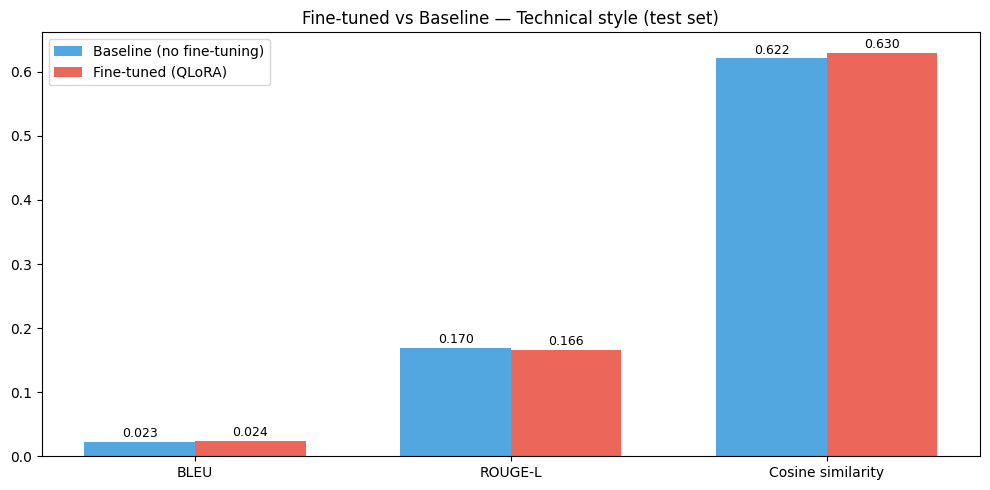


=== SUMMARY ===
BLEU                 baseline: 0.023 | fine-tuned: 0.024 | ↑ 7.1%
ROUGE-L              baseline: 0.170 | fine-tuned: 0.166 | ↓ 1.9%
Cosine similarity    baseline: 0.622 | fine-tuned: 0.630 | ↑ 1.4%


In [23]:
metrics = ["bleu", "rouge", "cosine"]
labels  = ["BLEU", "ROUGE-L", "Cosine similarity"]

baseline_means = [df_eval[f"{m}_baseline"].mean() for m in metrics]
ft_means       = [df_eval[f"{m}_ft"].mean()       for m in metrics]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, baseline_means, width, label="Baseline (no fine-tuning)", color="#3498db", alpha=0.85)
bars2 = ax.bar(x + width/2, ft_means,       width, label="Fine-tuned (QLoRA)",        color="#e74c3c", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("Fine-tuned vs Baseline — Technical style (test set)")
ax.legend()

for bar in [*bars1, *bars2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("finetuned_vs_baseline.png", dpi=150)
plt.show()

print("\n=== SUMMARY ===")
for m, label in zip(metrics, labels):
    b = df_eval[f"{m}_baseline"].mean()
    f = df_eval[f"{m}_ft"].mean()
    delta = ((f - b) / b) * 100
    arrow = "↑" if delta > 0 else "↓"
    print(f"{label:20} baseline: {b:.3f} | fine-tuned: {f:.3f} | {arrow} {abs(delta):.1f}%")

## 7 - Conclusion

### Results summary

| Approach | BLEU | ROUGE-L | Cosine | vs Baseline |
|---|---|---|---|---|
| Baseline — NB02 | 0.023 | 0.170 | 0.622 | — |
| RAG — NB04 | 0.029 | 0.165 | 0.665 | ↑ +3.6% cosine |
| LoRA Run 1 (epochs=3, lr=2e-4, r=16) | 0.026 | 0.167 | 0.593 | ↓ -4.6% cosine |
| LoRA Run 2 (epochs=1, lr=1e-4, r=8) | 0.024 | 0.166 | 0.630 | ↑ +1.4% cosine |

### Key findings

**Run 1 vs Run 2**: reducing epochs (3→1), learning rate (2e-4→1e-4) and
LoRA rank (16→8) eliminated overfitting and recovered the cosine degradation.
Run 2 is stable and shows a modest improvement over baseline.

**Fine-tuning vs RAG**: RAG remains the strongest approach on this dataset
(cosine 0.665 vs 0.630). This is expected — RAG directly injects Amazon-style
descriptions as few-shot examples, while fine-tuning is constrained by the
small training corpus (~680 examples).

**Why fine-tuning underperforms expectations**: three compounding factors:
- Dataset too small (~680 examples vs 5k-10k recommended for a 7B model)
- Sparse input features (title, brand, category, price only)
- Mistral 7B Instruct already performs well on this task out of the box —
  the improvement margin is inherently limited

### What fine-tuning brings despite modest scores

Although quantitative gains are limited, Run 2 produces more consistent
outputs — no repetition loops, no title copying, cleaner sentence structure.
This qualitative improvement is not fully captured by BLEU/ROUGE/cosine.

### Limitations

- Small training corpus — 5k+ examples would likely produce stronger gains
- Sparse input — richer metadata (features, attributes) would help both
  fine-tuning and baseline generation
- Evaluation bias — same issue as NB03/NB04, scores measure proximity to
  Amazon style not absolute quality

### Run 1 hyperparameters vs Run 2

| Parameter | Run 1 | Run 2 | Impact |
|---|---|---|---|
| epochs | 3 | 1 | Eliminated overfitting |
| learning_rate | 2e-4 | 1e-4 | More stable convergence |
| LoRA rank r | 16 | 8 | Reduced model capacity, less memorization |
| Best val loss | 1.338 | 1.387 | Run 1 lower but overfit |
| Cosine vs baseline | -4.6% | +1.4% | Run 2 generalizes better |

### Deployment decision

Run 2 is used for deployment in Notebook 06. Although RAG achieves better
quantitative scores, fine-tuning requires no retrieval step at inference —
lower latency, no corpus dependency, simpler architecture.

For a production system with a larger corpus and richer metadata, both
approaches would be worth combining (RAG + fine-tuned model).